In [ ]:
  %%capture
%pip install punchbowl

In [ ]:
import numpy as np

import glob

from astropy.io import fits

from sunpy.net import Fido
from sunpy.net import attrs as a

from punchbowl.data.punch_io import load_ndcube_from_fits
from punchbowl.data.visualize import cmap_punch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from punchbowl.util import nan_percentile

Let's grab some data for this F-corona exercise. You can pick other days, just edit the commented out examples below, making the file pattern and directory structure match. A few other examples are commented out below.

In [ ]:
!wget -r -l1 --no-parent --no-directories -A "PUNCH_L2_CTM_2025081100*_v0e.fits" -R "*.html*,index*,*tmp*" https://umbra.nascom.nasa.gov/punch/2/CTM/2025/08/11/
# !wget -r -l1 --no-parent --no-directories -A "PUNCH_L2_CTM_2025081101*_v0e.fits" -R "*.html*,index*,*tmp*" https://umbra.nascom.nasa.gov/punch/2/CTM/2025/08/11/
# !wget -r -l1 --no-parent --no-directories -A "PUNCH_L2_CTM_2025081103*_v0e.fits" -R "*.html*,index*,*tmp*" https://umbra.nascom.nasa.gov/punch/2/CTM/2025/08/11/

--2025-08-20 19:32:14--  https://umbra.nascom.nasa.gov/punch/2/CTM/2025/08/11/
Resolving umbra.nascom.nasa.gov (umbra.nascom.nasa.gov)... 198.118.248.134, 2001:4d0:14:100::134
Connecting to umbra.nascom.nasa.gov (umbra.nascom.nasa.gov)|198.118.248.134|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index.html.tmp’

index.html.tmp          [  <=>               ] 201.21K   903KB/s    in 0.2s    

2025-08-20 19:32:14 (903 KB/s) - ‘index.html.tmp’ saved [206038]

Loading robots.txt; please ignore errors.
--2025-08-20 19:32:15--  https://umbra.nascom.nasa.gov/robots.txt
Connecting to umbra.nascom.nasa.gov (umbra.nascom.nasa.gov)|198.118.248.134|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 441 [text/plain]
Saving to: ‘robots.txt.tmp’

robots.txt.tmp      100%[===================>]     441  --.-KB/s    in 0s      

2025-08-20 19:32:15 (173 MB/s) - ‘robots.txt.tmp’ saved [441/441]

Removing robots.txt.tm

In [ ]:
files = glob.glob('*.fits')
files.sort()
files

['PUNCH_L2_CTM_20250811000029_v0e.fits',
 'PUNCH_L2_CTM_20250811000829_v0e.fits',
 'PUNCH_L2_CTM_20250811001629_v0e.fits',
 'PUNCH_L2_CTM_20250811002429_v0e.fits',
 'PUNCH_L2_CTM_20250811003229_v0e.fits',
 'PUNCH_L2_CTM_20250811004029_v0e.fits',
 'PUNCH_L2_CTM_20250811004828_v0e.fits',
 'PUNCH_L2_CTM_20250811005629_v0e.fits']

We'll now load all the data at once.

In [ ]:
datacube = np.zeros( (len(files), 4096, 4096) )

for i, file in enumerate(files):
    cube = load_ndcube_from_fits(file)

    data = cube.data.copy()
    data[np.where(data == 0)] = np.nan
    datacube[i,:,:] = data

Below you can see the difference between two subsequent images in the data array.

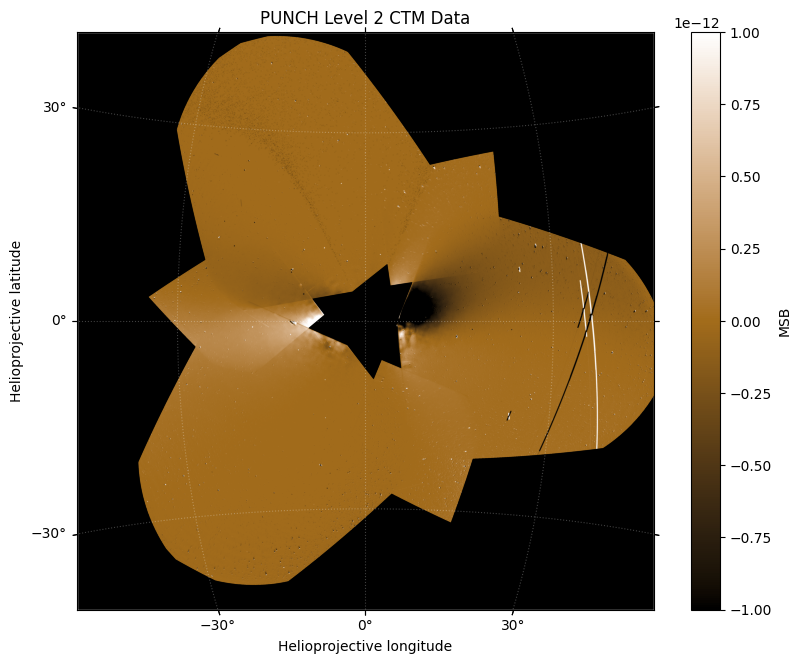

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={"projection":cube.wcs})

im = ax.imshow(datacube[1,:,:] - datacube[0,:,:], cmap=cmap_punch,
               vmin=-1e-12, vmax=1e-12)

lon, lat = ax.coords
lat.set_major_formatter("dd")
lon.set_major_formatter("dd")
ax.set_facecolor("black")
ax.coords.grid(color="white", alpha=.25, ls="dotted")
ax.set_xlabel("Helioprojective longitude")
ax.set_ylabel("Helioprojective latitude")
ax.set_title("PUNCH Level 2 CTM Data")
fig.colorbar(im, ax=ax, label="MSB")
plt.show()

The SOC uses a complex algorithm involving quadratic program and outlier rejection to create F-corona models. For today, we'll just take a low percentile of a bunch of images to determine an F-corona model. What do you think is the right number of images? Should they all be from the same date or should they be spread over a month? These are important questions to answer when building a model. We'll just use whatever data you downloaded for a first glance. Then, you can refine your data selection or use our provided F-corona model.

In [ ]:
ffcorona = nan_percentile(datacube, 5)[0]

Time to inspect the F-corona subtracted images!

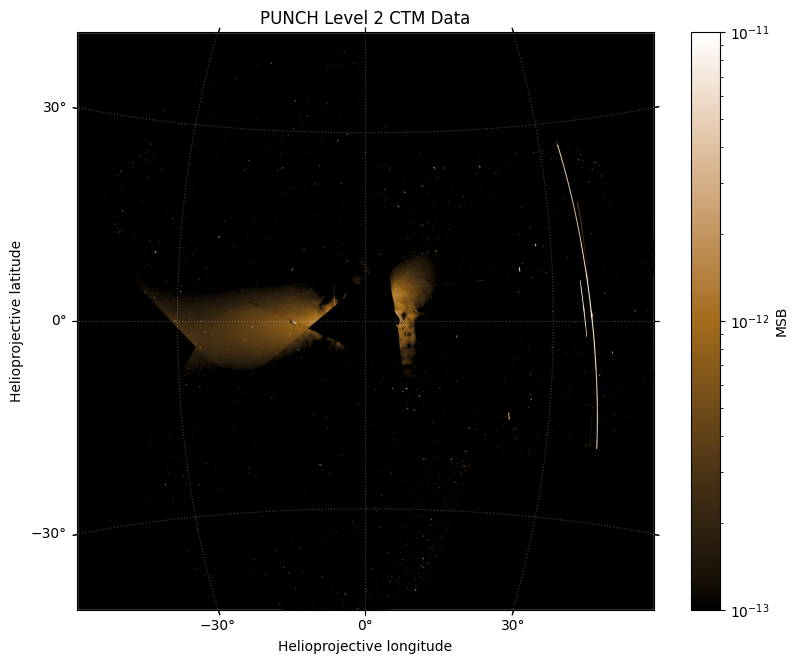

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={"projection":cube.wcs})

im = ax.imshow(datacube[1,:,:] - ffcorona, cmap=cmap_punch, norm=LogNorm(vmin=1e-13, vmax=1e-11))

lon, lat = ax.coords
lat.set_major_formatter("dd")
lon.set_major_formatter("dd")
ax.set_facecolor("black")
ax.coords.grid(color="white", alpha=.25, ls="dotted")
ax.set_xlabel("Helioprojective longitude")
ax.set_ylabel("Helioprojective latitude")
ax.set_title("PUNCH Level 2 CTM Data")
fig.colorbar(im, ax=ax, label="MSB")
plt.show()

You will need more data to build a higher quality F corona model. We've provided a model you can use to experiment at https://data.boulder.swri.edu/mhughes/punch_bimonthly/2025august/. Simply download it by clicking on the F-corona model saved there. Or run the following wget:

In [ ]:
!wget https://data.boulder.swri.edu/mhughes/punch_bimonthly/2025august/fcorona_20250530_204029.fits

--2025-08-21 07:01:38--  https://data.boulder.swri.edu/mhughes/punch_bimonthly/2025august/fcorona_20250530_204029.fits
Resolving data.boulder.swri.edu (data.boulder.swri.edu)... 10.15.241.16
Connecting to data.boulder.swri.edu (data.boulder.swri.edu)|10.15.241.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134222400 (128M) [image/fits]
Saving to: ‘fcorona_20250530_204029.fits’

fcorona_20250530_20 100%[===================>] 128.00M  38.8MB/s    in 3.3s    

2025-08-21 07:01:41 (38.7 MB/s) - ‘fcorona_20250530_204029.fits’ saved [134222400/134222400]



You can now load it:

In [ ]:
with fits.open("fcorona_20250530_204029.fits") as hdul:
    ffcorona = hdul[0].data

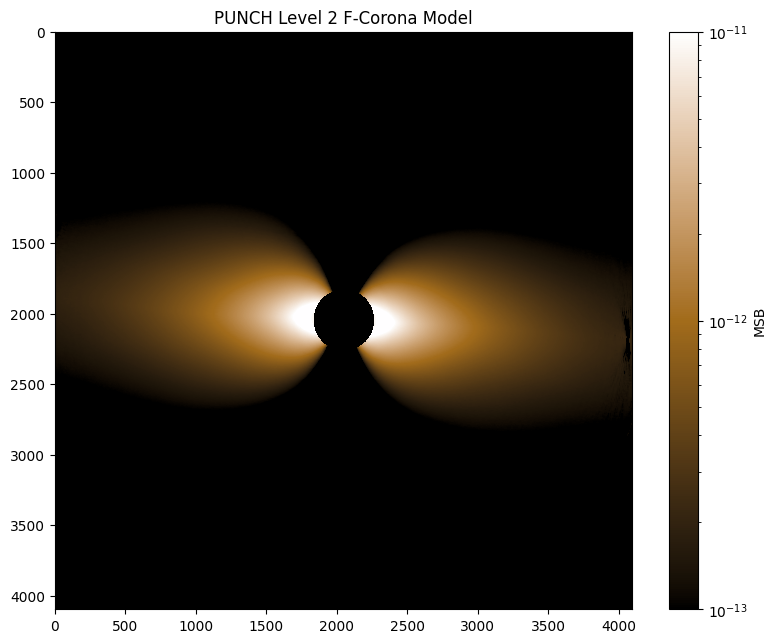

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 7.5))

im = ax.imshow(ffcorona, cmap=cmap_punch, norm=LogNorm(vmin=1E-13, vmax=1e-11))

ax.set_facecolor("black")
ax.set_title("PUNCH Level 2 F-Corona Model")
fig.colorbar(im, ax=ax, label="MSB")
plt.show()

Now you can explore data using this F-corona model to subtract off images. Finally, to make [a movie like Marcus showed](https://data.boulder.swri.edu/mhughes/punch_bimonthly/2025august/punch_movie.mp4), you can stack images using something like this followed by ffmpeg:

In [ ]:
from datetime import datetime
from glob import glob

import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib.colors import PowerNorm
from tqdm import tqdm

from punchbowl.data.visualize import cmap_punch

paths = sorted(glob("/path/to/level2/images"))  # BE SURE TO UPDATE THIS LINE!

rolling_frame =  []
previous = np.zeros((4096, 4096))

for path in tqdm(paths):
    with fits.open(path) as hdu:
        data = hdu[1].data
        mask = data != 0
        data -= ffcorona
        data[~mask] = np.nan
        date_obs = datetime.strptime(path.split("_")[5], "%Y%m%d%H%M%S")

    rolling_frame.append(data)
    if len(rolling_frame) > 10:
        rolling_frame.pop(0)

    static_frame = np.nanmean(rolling_frame, axis=0)

    fig, ax = plt.subplots(ncols=1, sharex=True, sharey=True, figsize=(4, 4))
    ax.imshow(static_frame, cmap=cmap_punch,
              norm = PowerNorm(gamma=1 / 2.2, vmin=9.5E-15, vmax=1E-12),
              origin = 'lower', interpolation = 'None')
    ax.set_facecolor('black')
    ax.set_axis_off()
    fig.tight_layout()
    fig.patch.set_facecolor('black')
    ax.text(0, 0, date_obs.strftime("%Y-%m-%d %H:%M:%S"), color='white')
    plt.savefig(path.replace(".fits", ".png"), dpi=300)
    plt.close()


0it [00:00, ?it/s]


```
ffmpeg -r 120 -f image2 -pattern_type glob -i "*png" -vcodec libx264 -crf 10 -pix_fmt yuv420p movie.mp4
```

Welcome to PUNCH data! We look forward to hearing what you discover!